In [2]:
import math


class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0

        self._backward = lambda: None

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)

        out = Value(t, (self,), "tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)

                for child in v._prev:
                    build_topo(child)

                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def exp(self):
        out = Value(math.exp(self.data), (self,), "exp")

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), \
            "only supporting int/float powers for now"

        out = Value(self.data**other, (self,), f"**{other}")

        def _backward():
            self.grad += other * self.data**(other - 1) * out.grad

        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other**-1

In [3]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)

            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

In [4]:
def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        dot.node(
            name=uid,
            label=f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}",
            shape="record"
        )

        if n._op:
            op_uid = uid + n._op
            dot.node(name=op_uid, label=n._op)
            dot.edge(op_uid, uid)

    for src, dst in edges:
        dot.edge(str(id(src)), str(id(dst)) + dst._op)

    return dot

neuron output: 0.7071067811865476
o.grad: 1.0
n.grad: 0.4999999999999999


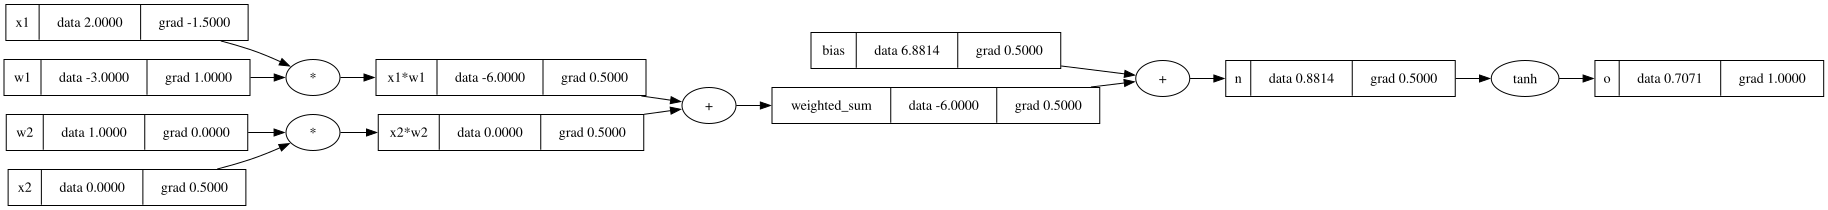

In [5]:
# 새 그래프를 만들어 이전 기울기가 누적되지 않게 합니다.
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

bias = Value(6.8813735870195432, label="bias")

x1w1 = x1 * w1
x1w1.label = "x1*w1"

x2w2 = x2 * w2
x2w2.label = "x2*w2"

weighted_sum = x1w1 + x2w2
weighted_sum.label = "weighted_sum"

n = weighted_sum + bias
n.label = "n"

o = n.tanh()
o.label = "o"

o.backward()

print("neuron output:", o.data)
print("o.grad:", o.grad)
print("n.grad:", n.grad)

draw_dot(o)

y.data: 6.0
x.grad: 2.0


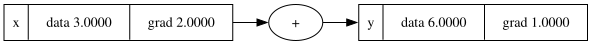

In [6]:
x = Value(3.0, label="x")
y = x + x
y.label = "y"

y.backward()

print(f"y.data: {y.data}")
print(f"x.grad: {x.grad}")

draw_dot(y)

y.data: 12.0
u.grad: 1.0
x.grad: 7.0


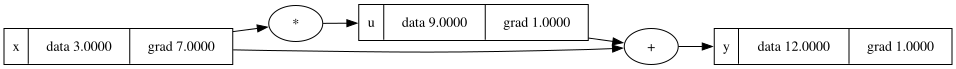

In [7]:
x = Value(3.0, label="x")

u = x * x
u.label = "u"

y = u + x
y.label = "y"

y.backward()

print(f"y.data: {y.data}")
print(f"u.grad: {u.grad}")
print(f"x.grad: {x.grad}")

draw_dot(y)

u.data: 0.0
z.data: 1.0
u.grad: 1.0
x.grad: 2.0


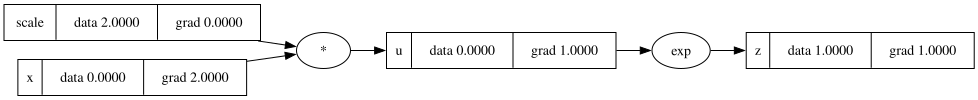

In [8]:
x = Value(0.0, label="x")
scale = Value(2.0, label="scale")

u = scale * x
u.label = "u"

z = u.exp()
z.label = "z"

z.backward()

print(f"u.data: {u.data}")
print(f"z.data: {z.data}")
print(f"u.grad: {u.grad}")
print(f"x.grad: {x.grad}")

draw_dot(z)

q.data: 3.0
a.grad: 0.5
b.grad: -1.5


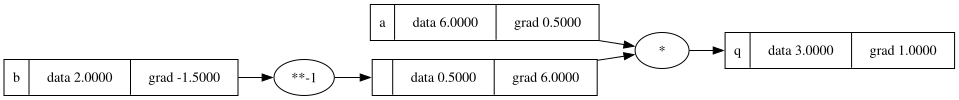

In [9]:
a = Value(6.0, label="a")
b = Value(2.0, label="b")

q = a / b
q.label = "q"

q.backward()

print(f"q.data: {q.data}")
print(f"a.grad: {a.grad}")
print(f"b.grad: {b.grad}")

draw_dot(q)

direct output: 0.7071067811865476
split output: 0.7071067811865477
direct input grad: 0.4999999999999999
split input grad: 0.5


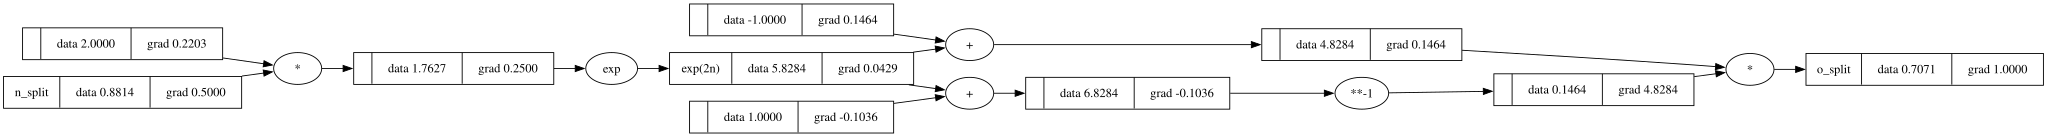

In [10]:
value = 0.8813735870195432

n_direct = Value(value, label="n_direct")
o_direct = n_direct.tanh()
o_direct.label = "o_direct"
o_direct.backward()

n_split = Value(value, label="n_split")
e = (2 * n_split).exp()
e.label = "exp(2n)"

o_split = (e - 1) / (e + 1)
o_split.label = "o_split"
o_split.backward()


print("direct output:", o_direct.data)
print("split output:", o_split.data)
print("direct input grad:", n_direct.grad)
print("split input grad:", n_split.grad)

draw_dot(o_split)

In [11]:
import torch

pt_x1 = torch.tensor([2.0], dtype=torch.float64, requires_grad=True)
pt_x2 = torch.tensor([0.0], dtype=torch.float64, requires_grad=True)

pt_w1 = torch.tensor([-3.0], dtype=torch.float64, requires_grad=True)
pt_w2 = torch.tensor([1.0], dtype=torch.float64, requires_grad=True)

pt_bias = torch.tensor(
    [6.8813735870195432],
    dtype=torch.float64,
    requires_grad=True,
)

pt_n = pt_x1 * pt_w1 + pt_x2 * pt_w2 + pt_bias
pt_o = torch.tanh(pt_n)

pt_o.backward()

print(f"pt_w1: {pt_w1}")

print("output shape:", pt_o.shape)
print("output:", pt_o.item())

print("x1.grad:", pt_x1.grad.item())
print("x2.grad:", pt_x2.grad.item())
print("w1.grad:", pt_w1.grad.item())
print("w2.grad:", pt_w2.grad.item())
print("bias.grad:", pt_bias.grad.item())

pt_w1: tensor([-3.], dtype=torch.float64, requires_grad=True)
output shape: torch.Size([1])
output: 0.7071067811865476
x1.grad: -1.4999999999999998
x2.grad: 0.49999999999999994
w1.grad: 0.9999999999999999
w2.grad: 0.0
bias.grad: 0.49999999999999994


In [12]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum(
            (wi * xi for wi, xi in zip(self.w, x)),
            self.b
        )
        return act.tanh()

    def parameters(self):
        return self.w + [self.b]

In [13]:
random.seed(42)

neuron = Neuron(3)
inputs = [2.0, 0.0, -1.0]

prediction = neuron(inputs)
prediction.backward()

print("output:", prediction.data)
print("parameter count:", len(neuron.parameters()))
print("weight grads:", [w.grad for w in neuron.w])
print("bias grad:", neuron.b.grad)

output: 0.42523882431234256
parameter count: 4
weight grads: [1.6383438845949132, 0.0, -0.8191719422974566]
bias grad: 0.8191719422974566


In [14]:
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [neuron(x) for neuron in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [
            p
            for neuron in self.neurons
            for p in neuron.parameters()
        ]

In [15]:
random.seed(42)

layer = Layer(3, 2)
outputs = layer([2.0, 0.0, -1.0])

print("outputs:", [out.data for out in outputs])
print("output count:", len(outputs))
print("parameter count:", len(layer.parameters()))

outputs: [0.42523882431234256, -0.5814143075168282]
output count: 2
parameter count: 8


In [16]:
class MLP:
    def __init__(self, nin, nouts):
        sizes = [nin] + nouts
        self.layers = [
            Layer(sizes[i], sizes[i + 1])
            for i in range(len(nouts))
        ]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [
            p
            for layer in self.layers
            for p in layer.parameters()
        ]

In [17]:
random.seed(42)

model = MLP(3, [4, 4, 1])
prediction = model([2.0, 3.0, -1.0])

print("prediction:", prediction.data)
print("layer parameter counts:",
      [len(layer.parameters()) for layer in model.layers])
print("total parameter count:", len(model.parameters()))

prediction: 0.6994093620224068
layer parameter counts: [16, 20, 5]
total parameter count: 41


In [18]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0]

In [19]:
predictions = [model(x) for x in xs]

squared_errors = [
    (prediction - target)**2
    for target, prediction in zip(ys, predictions)
]

loss = sum(squared_errors)

print("predictions:", [p.data for p in predictions])
print("targets:", ys)
print("squared errors:", [error.data for error in squared_errors])
print("loss:", loss.data)


predictions: [0.6994093620224068, 0.5026295816615511, 0.6931545900944501, 0.8755224728708613]
targets: [1.0, -1.0, -1.0, 1.0]
squared errors: [0.0903547316397765, 2.257895659684368, 2.8667724659579052, 0.015494654760185468]
loss: 5.230517512042234


In [20]:
for p in model.parameters():
    p.grad = 0.0

In [21]:
predictions = [model(x) for x in xs]
loss = sum(
    (prediction - target)**2
    for target, prediction in zip(ys, predictions)
)
before = loss.data

for p in model.parameters():
    p.grad = 0.0

loss.backward()

learning_rate = 0.1

for p in model.parameters():
    p.data -= learning_rate * p.grad

updated_predictions = [model(x) for x in xs]
updated_loss = sum(
    (prediction - target)**2
    for target, prediction in zip(ys, updated_predictions)
)

print("loss before:", before)
print("loss after:", updated_loss.data)
print("updated predictions:", [p.data for p in updated_predictions])

loss before: 5.230517512042234
loss after: 3.124109694204913
updated predictions: [-0.48531204806310413, -0.695721081414996, -0.43086416492229873, 0.29186402787413207]


In [22]:
learning_rate = 0.1

for step in range(20):
    predictions = [model(x) for x in xs]
    loss = sum(
        (prediction - target)**2
        for target, prediction in zip(ys, predictions)
    )

    for p in model.parameters():
        p.grad = 0.0

    loss.backward()

    for p in model.parameters():
        p.data -= learning_rate * p.grad

    print(f"step {step:02d} | loss before update: {loss.data:.6f}")

final_predictions = [model(x) for x in xs]
final_loss = sum(
    (prediction - target)**2
    for target, prediction in zip(ys, final_predictions)
)

print("final loss:", final_loss.data)
print("targets:", ys)
print("predictions:", [p.data for p in final_predictions])


step 00 | loss before update: 3.124110
step 01 | loss before update: 3.265975
step 02 | loss before update: 0.852220
step 03 | loss before update: 0.598029
step 04 | loss before update: 0.375133
step 05 | loss before update: 0.189506
step 06 | loss before update: 0.135847
step 07 | loss before update: 0.112981
step 08 | loss before update: 0.096349
step 09 | loss before update: 0.083704
step 10 | loss before update: 0.073794
step 11 | loss before update: 0.065837
step 12 | loss before update: 0.059321
step 13 | loss before update: 0.053897
step 14 | loss before update: 0.049317
step 15 | loss before update: 0.045405
step 16 | loss before update: 0.042027
step 17 | loss before update: 0.039084
step 18 | loss before update: 0.036499
step 19 | loss before update: 0.034212
final loss: 0.032175988241552406
targets: [1.0, -1.0, -1.0, 1.0]
predictions: [0.9089333683261238, -0.9532470904146848, -0.879746006890023, 0.9149353221158163]


In [23]:
from math import sin


def f(a, b, c):
    return -a**3 + sin(3*b) - 1.0/c + b**2.5 - a**0.5

In [24]:
from math import cos


def gradf(a, b, c):
    return [-3*a**2 - (0.5) * a**(-1/2), 3*cos(3*b) + 2.5 * b**1.5, 1/c**2]

print(gradf(2, 3, 4))

[-12.353553390593273, 10.25699027111255, 0.0625]


In [25]:
a, b, c = 2.0, 3.0, 4.0
h = 1e-6

numerical_grad = [
    (f(a + h, b, c) - f(a, b, c)) / h,
    (f(a, b + h, c) - f(a, b, c)) / h,
    (f(a, b, c + h) - f(a, b, c)) / h,
]

print(numerical_grad)

[-12.353559348809995, 10.256991666679482, 0.062499984743169534]


In [26]:
a, b, c = 2.0, 3.0, 4.0
h = 1e-6

numerical_grad2 = [
    (f(a + h, b, c) - f(a - h, b, c)) / (2*h),
    (f(a, b + h, c) - f(a, b - h, c)) / (2*h),
    (f(a, b, c + h) - f(a, b, c - h)) / (2*h),
]

expected = [-12.353553390593273, 10.25699027111255, 0.0625]

print("central differences:", numerical_grad2)
print("forward errors:",
      [abs(v - target) for v, target in zip(numerical_grad, expected)])
print("central errors:",
      [abs(v - target) for v, target in zip(numerical_grad2, expected)])

central differences: [-12.353553391353245, 10.25699027401572, 0.06250000028629188]
forward errors: [5.958216721779763e-06, 1.3955669331267018e-06, 1.5256830465659732e-08]
central errors: [7.599716411732516e-10, 2.9031710369054053e-09, 2.8629187909245957e-10]


In [34]:
from math import exp, log


class ExerciseValue:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"ExerciseValue(data={self.data})"

    def __add__(self, other):
        other = (
            other if isinstance(other, ExerciseValue)
            else ExerciseValue(other)
        )
        out = ExerciseValue(
            self.data + other.data, (self, other), "+"
        )

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward
        return out

    # TODO: 아래 공식 실습 실행에 필요한 연산들을 직접 구현
    def exp(self):
        out = ExerciseValue(exp(self.data), (self,), _op="exp")

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward

        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        if not isinstance(other, ExerciseValue):
            other = ExerciseValue(other)

        out = ExerciseValue(self.data * other.data, (self, other), _op="*")

        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data

        out._backward = _backward

        return out

    def __pow__(self, other):
        out = ExerciseValue(self.data**other, _children=(self,), _op=f"**{other}")

        def _backward():
            self.grad += other * self.data**(other-1) * out.grad

        out._backward = _backward

        return out

    def __truediv__(self, other):
        return self * (other**-1)

    def __neg__(self):
        return self*-1

    def log(self):
        out = ExerciseValue(log(self.data), _children=(self,), _op="log")

        def _backward():
            self.grad += out.grad / self.data

        out._backward = _backward

        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

In [35]:
def softmax(logits):
    counts = [logit.exp() for logit in logits]
    denominator = sum(counts)
    return [count / denominator for count in counts]


logits = [
    ExerciseValue(0.0),
    ExerciseValue(3.0),
    ExerciseValue(-2.0),
    ExerciseValue(1.0),
]

probs = softmax(logits)
loss = -probs[3].log()
loss.backward()

print("probabilities:", [p.data for p in probs])
print("loss:", loss.data)

expected = [
    0.041772570515350445,
    0.8390245074625319,
    0.005653302662216329,
    -0.8864503806400986,
]

for i, target in enumerate(expected):
    actual = logits[i].grad
    status = "OK" if abs(actual - target) < 1e-5 else "WRONG"
    print(i, status, "expected:", target, "actual:", actual)

probabilities: [0.04177257051535045, 0.839024507462532, 0.00565330266221633, 0.11354961935990122]
loss: 2.1755153626167147
0 OK expected: 0.041772570515350445 actual: 0.041772570515350445
1 OK expected: 0.8390245074625319 actual: 0.8390245074625319
2 OK expected: 0.005653302662216329 actual: 0.005653302662216329
3 OK expected: -0.8864503806400986 actual: -0.8864503806400986


In [37]:
torch_logits = torch.tensor(
    [0.0, 3.0, -2.0, 1.0],
    dtype=torch.float64,
    requires_grad=True
)

probs = torch.softmax(torch_logits, dim=0)
loss = -probs[3].log()
loss.backward()

print(f"loss: {loss}")
print(f"torch_logits.grad: {torch_logits.grad}")

loss: 2.1755153626167143
torch_logits.grad: tensor([ 0.0418,  0.8390,  0.0057, -0.8865], dtype=torch.float64)
